# A/B-тест SollmaFin: анализ нового онбординга

**Автор:** Гаскарова Аида  
**Инструменты:** Python, pandas, numpy, scipy, matplotlib, seaborn  

---

## Контекст

Fintech-сервис SollmaFin обновил онбординг инвестиционного приложения: новый флоу содержит подробную информацию о рисках активов. Цель эксперимента — проверить, улучшает ли новый онбординг вовлечённость и монетизацию пользователей.

---

## Содержимое

**Часть 1. Исторические данные**

1. [Загрузка исторических данных и их предобработка](#1.-Загрузка-исторических-данных-и-их-предобработка)
2. [Исследовательский анализ исторических данных](#2.-Исследовательский-анализ-исторических-данных)

**Часть 2. A/B-эксперимент**

3. [Исследование результатов A/B-эксперимента](#3.-Исследование-результатов-А/В-эксперимента)
4. [Анализ изменений суммы депозитов на платящего пользователя (Bootstrap)](#4.-Анализ-изменений-суммы-депозитов-на-платящего-пользователя)
5. [Общие выводы и рекомендации](#5.-Выводы)


---

## Часть 1

### 1. Загрузка исторических данных и их предобработка

Загрузите данные из датасета `/datasets/pa_sollmafin_hist.csv` и получите основную информацию о них. Проведите предобработку. Зафиксируйте основную информацию о данных и предобработке в кратком промежуточном выводе.

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind

In [2]:
# Функция отображения информации
def info_summary(dataframe):
    display(dataframe.head(5))
    display(dataframe.info())
    display(dataframe.describe(percentiles = [0.05, 0.5, 0.95, 0.99]))

In [3]:
hist = pd.read_csv('https://code.s3.yandex.net/datasets/pa_sollmafin_hist.csv')

In [4]:
info_summary(hist)

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,amount,asset,risk_level
0,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:51,install / open_web,NaN,NaN,NaN
1,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:59,introduction,NaN,NaN,NaN
2,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:06,registration,NaN,NaN,NaN
3,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:15,main_page,NaN,NaN,NaN
4,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:47:59,onboarding_complete,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238059 entries, 0 to 238058
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   user_id       238059 non-null  object 
 1   country_code  238059 non-null  object 
 2   platform      238059 non-null  object 
 3   first_ts      238059 non-null  object 
 4   first_dt      238059 non-null  object 
 5   event_ts      238059 non-null  object 
 6   event_name    238059 non-null  object 
 7   amount        33093 non-null   float64
 8   asset         15392 non-null   object 
 9   risk_level    15392 non-null   object 
dtypes: float64(1), object(9)
memory usage: 18.2+ MB


None

,amount
count,33093.000000
mean,113.527967
std,34.472458
min,27.000000
5%,67.000000
50%,109.000000
95%,175.000000
99%,222.000000
max,524.000000


In [5]:
# Приводим в корректный формат даты
hist['first_ts'] = pd.to_datetime(hist['first_ts'])
hist['first_dt'] = pd.to_datetime(hist['first_dt'])
hist['event_ts'] = pd.to_datetime(hist['event_ts'])

In [6]:
# Проверяем на явные и неявные дубликаты
print(f"Количество явных дубликатов: {hist.duplicated().sum()}")

# Проверим на неявные дубликаты по полям 'user_id','datetime','event'
duplicates = hist.duplicated(subset=['user_id', 'first_ts', 'first_dt', 'event_ts'], keep=False)
num_duplicates = duplicates.sum()

print(f"Количество неявных дубликатов: {num_duplicates}")

Количество явных дубликатов: 0
Количество неявных дубликатов: 0


In [7]:
# Базовые проверки корректности значений
print(f"Уникальные страны: {hist['country_code'].unique()}")
print(f"Уникальные платформы: {hist['platform'].unique()}")
print(f"Кол-во уникальных пользователей: {hist['user_id'].nunique()}")

# Последовательность событий пользователя
print(f"Возможные события для пользователя: {hist['event_name'].unique()}")

Уникальные страны: ['BR' 'AR' 'CO' 'MX']
Уникальные платформы: ['mobile' 'web']
Кол-во уникальных пользователей: 41032
Возможные события для пользователя: ['install / open_web' 'introduction' 'registration' 'main_page'
 'onboarding_complete' 'first_deposit' 'asset_purchase' 'second_deposit']


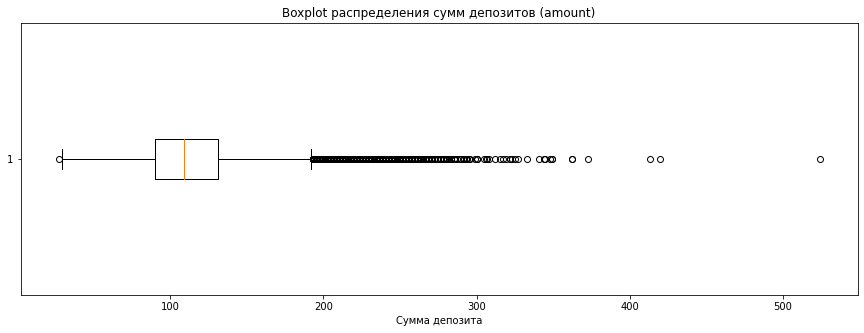

In [8]:
# Проверка на выбросы по метрике amount
# Отбираем только события с депозитом
deposit_amounts = hist.loc[hist['amount'].notna(), 'amount']

plt.figure(figsize=(15, 5))
plt.boxplot(deposit_amounts, vert=False)
plt.title('Boxplot распределения сумм депозитов (amount)')
plt.xlabel('Сумма депозита')
plt.show()

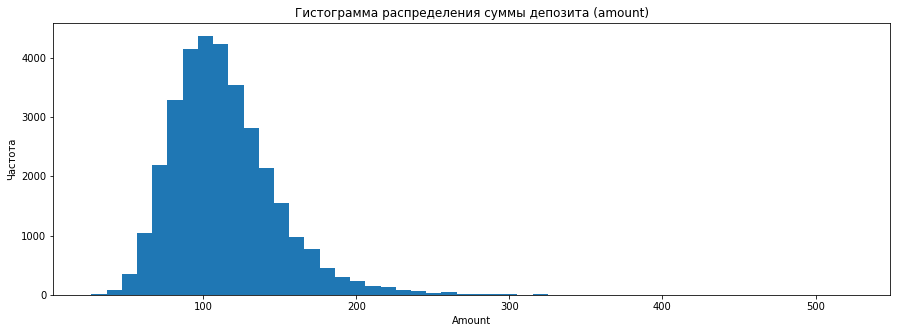

In [9]:
# Построим гистограмму распределения
plt.figure(figsize=(15, 5))
plt.hist(hist['amount'], bins=50)
plt.title('Гистограмма распределения суммы депозита (amount)')
plt.xlabel('Amount')
plt.ylabel('Частота')
plt.show()

По гистограмме видно, что распределение асимметричное с длинным правым хвостом. Среднее значение равно 113.5, медиана - 109.0, стандартное отклонение - 34.5. 
У основной масса пользователей сумма депозита сконцентрированы примерно в диапазоне 80–150.
Пик распределения — около 100–110, что хорошо согласуется с ранее рассчитанной медианой и средним.

Есть небольшая, но заметная группа пользователей с депозитами 200+, вплоть до 600–650
Отфильтруем датафрейм, оставив значения меньше 99-ого процентиля.

In [10]:
# Определяем 99 процентиль для `amount` и фильтруем датасет 
p99 = hist['amount'].quantile(0.99)
hist = hist[(hist['amount'].isna()) | (hist['amount'] <= p99)]
info_summary(hist)

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,amount,asset,risk_level
0,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:51,install / open_web,NaN,NaN,NaN
1,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:59,introduction,NaN,NaN,NaN
2,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:06,registration,NaN,NaN,NaN
3,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:15,main_page,NaN,NaN,NaN
4,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:47:59,onboarding_complete,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
Int64Index: 237730 entries, 0 to 238058
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       237730 non-null  object        
 1   country_code  237730 non-null  object        
 2   platform      237730 non-null  object        
 3   first_ts      237730 non-null  datetime64[ns]
 4   first_dt      237730 non-null  datetime64[ns]
 5   event_ts      237730 non-null  datetime64[ns]
 6   event_name    237730 non-null  object        
 7   amount        32764 non-null   float64       
 8   asset         15392 non-null   object        
 9   risk_level    15392 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(6)
memory usage: 20.0+ MB


None

,amount
count,32764.000000
mean,112.108992
std,31.392254
min,27.000000
5%,67.000000
50%,108.000000
95%,171.000000
99%,201.000000
max,222.000000


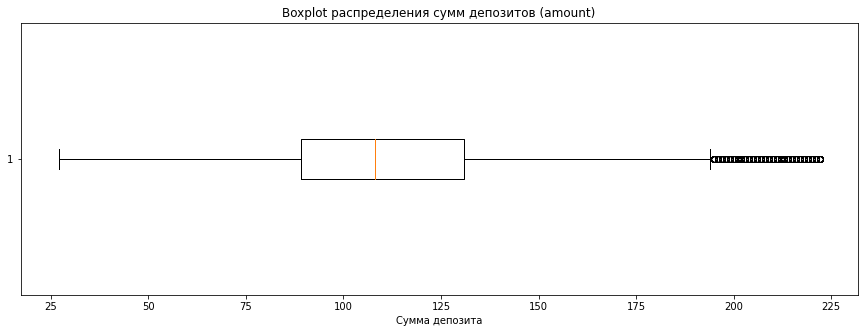

In [11]:
# Проверка на выбросы по метрике amount
# после очистки выбросов
# Отбираем только события с депозитом
deposit_amounts = hist.loc[hist['amount'].notna(), 'amount']

plt.figure(figsize=(15, 5))
plt.boxplot(deposit_amounts, vert=False)
plt.title('Boxplot распределения сумм депозитов (amount)')
plt.xlabel('Сумма депозита')
plt.show()

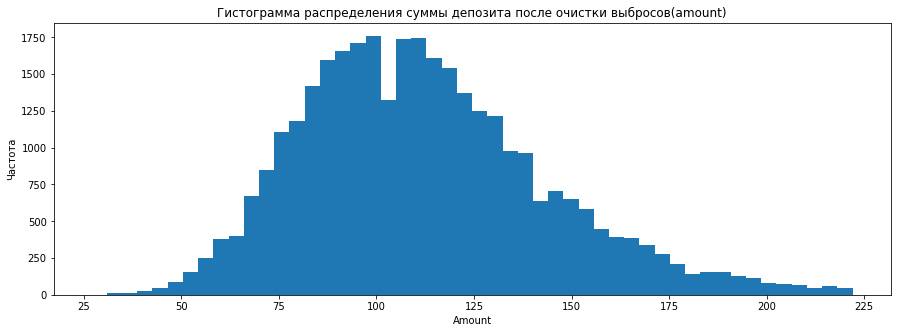

In [12]:
# Построим  гистограмму распределения 
# после очистки выбросов
plt.figure(figsize=(15, 5))
plt.hist(hist['amount'], bins=50)
plt.title('Гистограмма распределения суммы депозита после очистки выбросов(amount)')
plt.xlabel('Amount')
plt.ylabel('Частота')
plt.show()

В итоге мы убрали крупные единичные депозиты и будем анализировать поведение без аномальных чеков.

***Выводы:*** 
Датасет содержит 238 059 строк и 10 столбцов. После очистки выбросов(анамально крупных единичных депозитов) по 99 процентилю 237 730 строк. 
Представляет собой событийный лог, где каждая строка соответствует отдельному действию пользователя в приложении. 
- `user_id`, `country_code`, `platform`, `event_name`, `first_ts`, `first_dt`, `event_ts` заполнены на 100%.
- `amoun`t заполнен примерно в 14% строк → соответствует событиям депозита.
- `asset` и `risk_level` заполнены примерно в 6,5% строк → соответствует событиям покупки активов.
Пропуски в финансовых полях являются ожидаемыми и отражают разные типы событий, а не проблемы качества данных.

Последовательность событий для пользователя: 'install / open_web → introduction → registration → main_page → onboarding_complete → first_deposit → asset_purchase → second_deposit.

---

### 2. Исследовательский анализ исторических данных

Проведите исследовательский анализ исторических данных. По каждой подзадаче сделайте промежуточный вывод. 

**Задача 2.1.** Анализ новых пользователей.
- Изучите динамику привлечения новых пользователей в приложение.

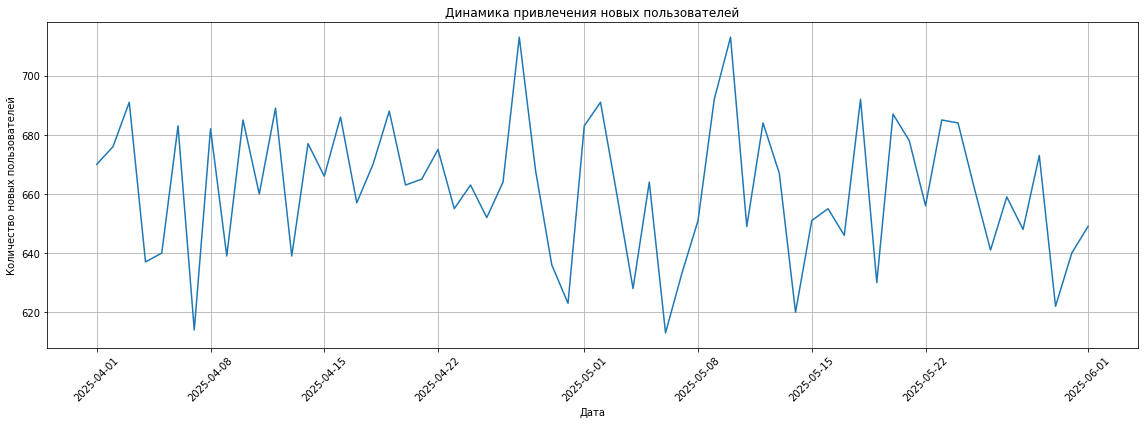

In [13]:
# Число новых пользователей по дням
daily_new_users = (
    hist
    .groupby('first_dt')
    .agg(new_users=('user_id', 'nunique'))
    .reset_index()
)

# Визуализация динамики новых пользователей
plt.figure(figsize=(16, 6))
plt.plot(daily_new_users['first_dt'], daily_new_users['new_users'])
plt.title('Динамика привлечения новых пользователей')
plt.xlabel('Дата')
plt.ylabel('Количество новых пользователей')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

На графике количество новых пользователей ежедневно колеблется в диапазоне примерно от ~610 до ~725 человек в день.
Динамика привлечения новых пользователей в период с начала апреля по начало июня 2025 года сохраняла стабильный уровень с умеренными колебаниями по дням. Явных трендов к росту или спаду не наблюдается, а кратковременные пики, вероятно, связаны с маркетинговыми активностями или сезонными эффектами. В целом приток новых пользователей устойчив.

Изучим динамику привлечения новых пользователей в разрезе стран.

<function matplotlib.pyplot.show(close=None, block=None)>

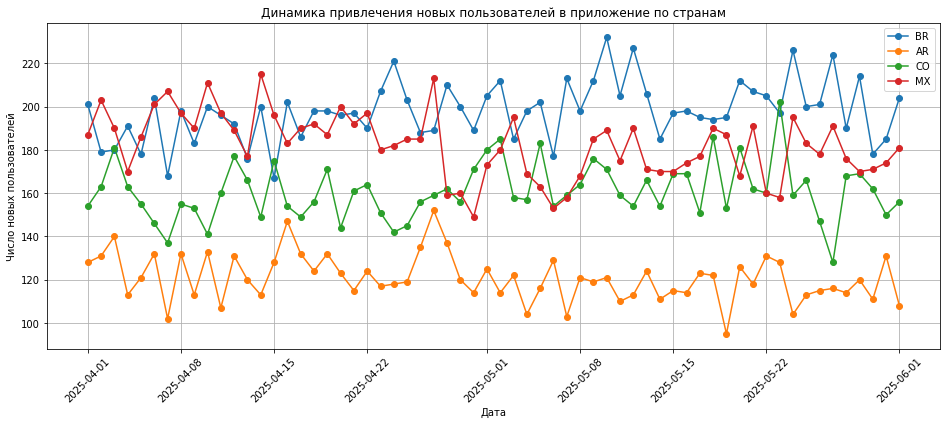

In [14]:
# Число новых пользователей по дням в разрезе стран
new_users_country = (
    hist
    .groupby(['first_dt', 'country_code'])
    .agg(new_users=('user_id', 'nunique'))
    .reset_index()
)

# Визуализация динамики новых пользователей
plt.figure(figsize=(16, 6))
for country in hist['country_code'].unique():
    df_plot = new_users_country[new_users_country['country_code'] == country]
    plt.plot(df_plot['first_dt'], df_plot['new_users'], marker='o', label = country)

plt.title('Динамика привлечения новых пользователей в приложение по странам')
plt.xlabel('Дата')
plt.xticks(rotation=45)
plt.ylabel('Число новых пользователей')
plt.legend()
plt.grid(True)
plt.show

- Бразилия (BR) демонстрирует наибольший объём привлечения в среднем ~190–210 новых пользователей в день, периодические пики выше 220.
Это основной рынок продукта по объёму аудитории.
- Мексика (MX) стабильный приток ~170–190 пользователей в день, умеренная волатильность.
Колумбия (CO) чуть меньшие значения (~145–175), более заметные колебания.
- Аргентина (AR) стабильно привлекает меньше пользователей примерно 110–130 в день. Волатильность низкая, тренда роста не наблюдается.

Отсутствие резких изменений в динамике создаёт корректный фон для интерпретации результатов A/B-эксперимента по обновлённому онбордингу.

Изучим динамику привлечения новых пользователей по платформам.

<function matplotlib.pyplot.show(close=None, block=None)>

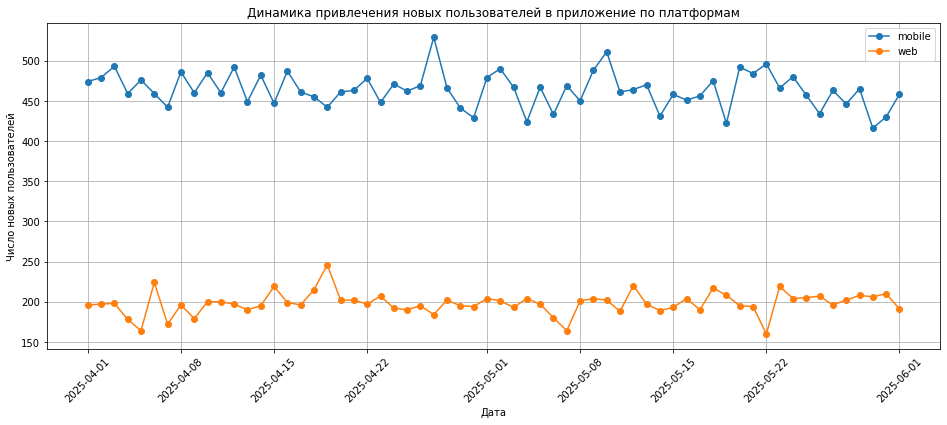

In [15]:
# Число новых пользователей по дням в разрезе платформ
new_users_platform = (
    hist
    .groupby(['first_dt', 'platform'])
    .agg(new_users=('user_id', 'nunique'))
    .reset_index()
)

# Визуализация динамики новых пользователей
plt.figure(figsize=(16, 6))
for platform in hist['platform'].unique():
    df_plot = new_users_platform[new_users_platform['platform'] == platform ]
    plt.plot(df_plot['first_dt'], df_plot['new_users'], marker='o', label = platform )

plt.title('Динамика привлечения новых пользователей в приложение по платформам')
plt.xlabel('Дата')
plt.xticks(rotation=45)
plt.ylabel('Число новых пользователей')
plt.legend()
plt.grid(True)
plt.show

Через мобильное приложение приходит в~1,5-2 раза больше пользователей. Динамика по дням стабильная.

**Задача 2.2.** Анализ воронок событий.
- Постройте классическую и пошаговую воронки;
- Охарактеризуйте пользовательский путь в приложении и определите узкие места воронки. 


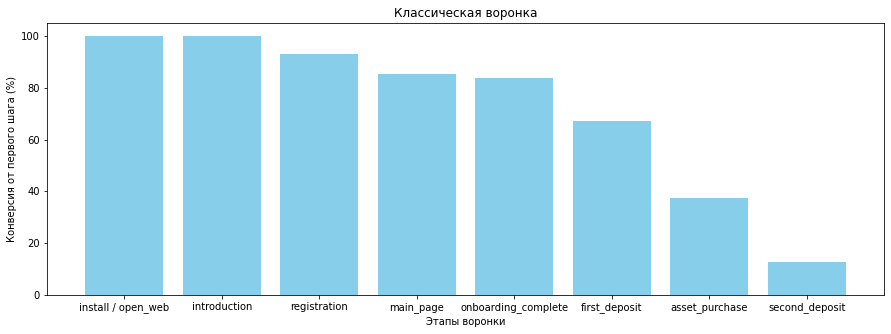

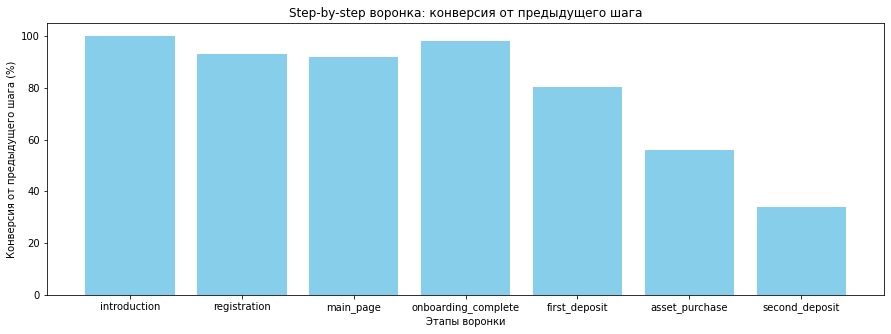

,step,users,conversion_from_first_%,conversion_from_previous_%
0,install / open_web,41032,100.0,NaN
1,introduction,41032,100.0,100.0
2,registration,38133,92.9,92.9
3,main_page,35040,85.4,91.9
4,onboarding_complete,34337,83.7,98.0
5,first_deposit,27560,67.2,80.3
6,asset_purchase,15392,37.5,55.8
7,second_deposit,5204,12.7,33.8


In [16]:
# Классическая воронка
# Задаем порядок шагов в воронке
funnel_steps = ['install / open_web',
                'introduction',
                'registration',
                'main_page',
                'onboarding_complete',
                'first_deposit',
                'asset_purchase',
                'second_deposit']

# Фильтруем датасет оставляя только нужные шаги воронки
hist_steps = hist[hist['event_name'].isin(funnel_steps)]

# Считаем число уникальных пользователей на каждом шаге
hist_counts = hist_steps.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)

# Собираем таблицу воронки
funnel_df = pd.DataFrame({
    'step': funnel_steps,
    'users': hist_counts.values
}) 

# Добавляем конверсии
funnel_df['conversion_from_first_%'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(1)
funnel_df['conversion_from_previous_%'] = (funnel_df['users'] / funnel_df['users'].shift(1) * 100).round(1)

# Визуализируем данные, классическая воронка 
plt.figure(figsize=(15, 5))
# Строим barplot
plt.bar(funnel_df['step'], funnel_df['conversion_from_first_%'], color='skyblue')
plt.title('Классическая воронка')
plt.ylabel('Конверсия от первого шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

# Визуализируем данные, воронка step-by-step
plt.figure(figsize=(15, 5))
# Строим barplot
plt.bar(funnel_df['step'], funnel_df['conversion_from_previous_%'], color='skyblue')
plt.title('Step-by-step воронка: конверсия от предыдущего шага')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.show()

funnel_df

***Выводы:*** 
Пользователь в приложении проходит такой путь:
`install / open_web` — установка приложения/открытие web страницы;
`introduction` — знакомство с продуктом;
`registration` — регистрация;
`main_page` — личная страница;
`onboarding_complete` — настройка личной страницы;
`first_deposit` — внесение первого депозита;
`asset_purchase` — сделка;
`second_deposit` - внесение второго депозита.
Практически все пользователи, которые установили приложение, доходят до `onboarding_complete`.
Конверсии на этих шагах очень высокие — потери минимальны (<15%).
Это говорит о корректной активации и базовом UX — процесс регистрации и онбординга понятен и не вызывает значительного оттока.

С переходом к шагу `first_deposit` (пополнение первого депозита) видим заметный спад.
Здесь сразу видим, что многие пользователи не готовы вносить деньги на брокерский счёт.

Падение конверсии после `first_deposit` → `asset_purchase` весьма сильное (примерно ~35–40% остаются).
Это указывает на то, что часть пользователей:
- внесли деньги, но не решились купить актив;
- возможно, не понимают, как совершать сделки.

И самый низкий показатель — на этапе `second_deposit` (примерно 30–35% от тех, кто купил актив).
Это означает, что большинству пользователей недостаточно опыта первой покупки, чтобы:
- вернуться и внести деньги снова;
- почувствовать уверенность в продукте;
- обрести мотивацию для продолжения инвестиций.

**Задача 2.3.** Влияние уровня риска актива на открытие второго депозита.
- Изучите, как уровень риска первого актива влияет на конверсию во второй депозит.  

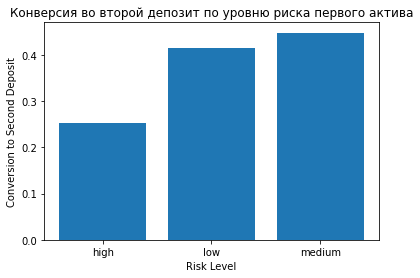

,risk_level,total_buyers,buyers_with_sec_dep,conv_to_second_dep
0,high,7740,1955.0,0.252584
1,low,2327,1043.0,0.448217
2,medium,5325,2206.0,0.414272


In [17]:
# Берём пользователей, которые купили актив
first_purchases = (
    hist[hist['event_name']=='asset_purchase']
    .sort_values(['user_id','event_ts'])
    .groupby('user_id')
    .first()   # первая покупка актива
    .reset_index()[['user_id','risk_level']]
)

# Отбираем пользователь, которые сделали второй депозит
second_deps = (
    hist[hist['event_name']=='second_deposit']
    .groupby('user_id')
    .size()
    .reset_index(name='sec_dep_cnt')
)

#  Объединяем
df = first_purchases.merge(second_deps, on='user_id', how='left')

# Заполняем 0 (если второй депозит не сделан)
df['sec_dep_cnt'] = df['sec_dep_cnt'].fillna(0)

# Считаем по уровням риска
result = (
    df.groupby('risk_level')
      .agg(
          total_buyers = ('user_id','nunique'),
          buyers_with_sec_dep = ('sec_dep_cnt', lambda s: (s > 0).sum())
      )
      .reset_index()
)

# Конверсия во второй депозит
result['conv_to_second_dep'] = result['buyers_with_sec_dep'] / result['total_buyers']

result

# Визуализация
plt.figure(figsize=(6,4))
plt.bar(result['risk_level'], result['conv_to_second_dep'].sort_values())
plt.title('Конверсия во второй депозит по уровню риска первого актива')
plt.xlabel('Risk Level')
plt.ylabel('Conversion to Second Deposit')
plt.show()
result

***Выводы:*** Конверсия во второй депозит заметно различается между группами пользователей в зависимости от риска первого купленного актива. Это означает, что первый инвестиционный опыт напрямую связан с дальнейшей вовлечённостью.
- Конверсия во второй депозит для пользователей, выбравших `high-risk` актив, является самой низкой среди всех групп.
Это указывает на то, что первый опыт с высокими рисками часто оказывается негативным:возможные быстрые потери, разочарование, снижение доверия к продукту.
- Пользователи, выбравшие `low` и `medium risk` активы, значительно чаще открывают второй депозит.
Наиболее высокая конверсия наблюдается у группы `medium risk`: пользователи получают баланс между потенциальной доходностью и контролируемым риском,
опыт инвестирования оказывается менее стрессовым и более мотивирующим.


**Задача 2.4.** Анализ ключевой метрики на исторических данных.
- На исторических данных рассчитайте значение ключевой метрики — средней суммы всех депозитов на одного пользователя. Учитывайте всех пользователей, которые взаимодействовали с сервисом. Это позволит зафиксировать базовый уровень монетизации.
- Визуализируйте данные, где необходимо. По результатам исследовательского анализа сделайте краткий вывод. 

Средняя сумма депозитов на пользователя: 89.52
Стандартное отклонение суммы депозитов: 77.39


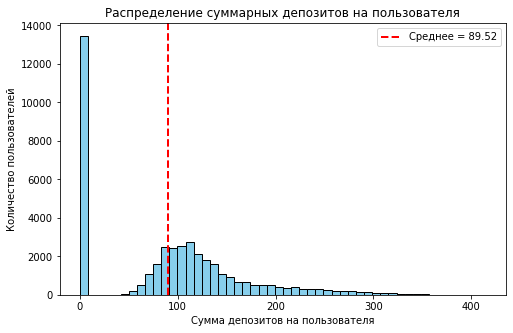

In [18]:
# Считаем суммарные депозиты по пользователю
deposit_events = hist[hist['event_name'].isin(['first_deposit','second_deposit'])].copy()
user_deposits = deposit_events.groupby('user_id')['amount'].sum().reset_index(name='total_deposit')

# Добавляем пользователей без депозитов (их суммы = 0)
all_users = hist[['user_id']].drop_duplicates()
user_deposits_full = all_users.merge(user_deposits, on='user_id', how='left')
user_deposits_full['total_deposit'] = user_deposits_full['total_deposit'].fillna(0)

# Среднее значение (ключевая метрика)
avg_deposit_per_user = user_deposits_full['total_deposit'].mean()
std_deposit_per_user = user_deposits_full['total_deposit'].std()

print(f"Средняя сумма депозитов на пользователя: {avg_deposit_per_user:.2f}")
print(f"Стандартное отклонение суммы депозитов: {std_deposit_per_user:.2f}")

# Визуализация: гистограмма распределения депозитов
plt.figure(figsize=(8,5))
plt.hist(user_deposits_full['total_deposit'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(avg_deposit_per_user, color='red', linestyle='--', linewidth=2,
            label=f'Среднее = {avg_deposit_per_user:.2f}')
plt.title('Распределение суммарных депозитов на пользователя')
plt.xlabel('Сумма депозитов на пользователя')
plt.ylabel('Количество пользователей')
plt.legend()
plt.show()

***Выводы:*** 
- Самый высокий столбец на нуле — это пользователи, которые не внесли ни единого депозита.
Это закономерно для финансовых приложений: многие регистрируются, но не переходят к денежным операциям.
- Средняя (ARPU) ≈ 90. Красная пунктирная линия показывает среднее значение суммы депозитов на пользователя.
Это ключевой показатель монетизации, который включает по условию задачи всех пользователей: неплатящих (0) и платящих с разными суммами.
- Для платящих пользователей распределение вкладов распределено непрерывно вправо:
  - большинство платящих инвестируют суммы в диапазоне примерно 80-150;
  - дальше идут более редкие, но крупные депозиты (300-400);
  - длинный правый хвост формируется за счёт пользователей, совершивших несколько депозитов,
либо увеличивающих сумму пополнений со временем.
- Среднее значение = 89.5 и Std = 77.4 показывают, что суммы депозитов сильно варьируются: средний депозит выше типичного за счёт крупного хвоста, а не из-за общего роста платежей у большинства пользователей.

---

## Часть 2

### 3. Исследование результатов А/В эксперимента
Загрузите данные с результатами эксперимента (датасет `/datasets/pa_sollmafin_abt.csv `). Проверьте корректность данных и проведите предобработку. Зафиксируйте основную информацию о данных и предобработке в кратком промежуточном выводе.
Затем проведите анализ результатов А/В-эксперимента.


In [19]:
abt = pd.read_csv('https://code.s3.yandex.net//datasets/pa_sollmafin_abt.csv')

In [20]:
info_summary(abt)

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,ab_test,group,amount,asset,risk_level
0,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:51,install / open_web,onboarding_test,test,NaN,NaN,NaN
1,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:54,introduction,onboarding_test,test,NaN,NaN,NaN
2,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:09,registration,onboarding_test,test,NaN,NaN,NaN
3,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:13,main_page,onboarding_test,test,NaN,NaN,NaN
4,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:33:40,onboarding_complete,onboarding_test,test,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54805 entries, 0 to 54804
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       54805 non-null  object 
 1   country_code  54805 non-null  object 
 2   platform      54805 non-null  object 
 3   first_ts      54805 non-null  object 
 4   first_dt      54805 non-null  object 
 5   event_ts      54805 non-null  object 
 6   event_name    54805 non-null  object 
 7   ab_test       54805 non-null  object 
 8   group         54805 non-null  object 
 9   amount        7843 non-null   float64
 10  asset         3750 non-null   object 
 11  risk_level    3750 non-null   object 
dtypes: float64(1), object(11)
memory usage: 5.0+ MB


None

,amount
count,7843.000000
mean,109.620681
std,86.604702
min,25.000000
5%,25.000000
50%,97.000000
95%,233.000000
99%,502.000000
max,1050.000000


In [21]:
# Приводим в корректный формат даты
abt['first_ts'] = pd.to_datetime(abt['first_ts'])
abt['first_dt'] = pd.to_datetime(abt['first_dt'])
abt['event_ts'] = pd.to_datetime(abt['event_ts'])

In [22]:
# Проверяем что даты соответствуют условию задания:
# В эксперименте участвовали новые пользователи, которые зарегистрировались в приложении со 2 по 15 июня 2025 года
print(f"Минимальная дата регистрации в приложении {abt['first_dt'].min()}")
print(f"Максимальная дата регистрации в приложении {abt['first_dt'].max()}")

# После разделения активность пользователей анализировали в течение недели
print(f"Максимальная дата активности в приложении {abt['event_ts'].max()}")

Минимальная дата регистрации в приложении 2025-06-02 00:00:00
Максимальная дата регистрации в приложении 2025-06-15 00:00:00
Максимальная дата активности в приложении 2025-06-22 13:37:05


In [23]:
# Проверяем на явные и неявные дубликаты
print(f"Количество явных дубликатов: {abt.duplicated().sum()}")

# Проверим на неявные дубликаты по полям 'user_id','datetime','event'
duplicates = abt.duplicated(subset=['user_id', 'first_ts', 'first_dt', 'event_ts'], keep=False)
num_duplicates = duplicates.sum()

print(f"Количество неявных дубликатов: {num_duplicates}")

Количество явных дубликатов: 0
Количество неявных дубликатов: 0


In [24]:
# Базовые проверки корректности значений
print(f"Уникальные страны: {abt['country_code'].unique()}")
print(f"Уникальные платформы: {abt['platform'].unique()}")
print(f"Кол-во уникальных пользователей: {abt['user_id'].nunique()}")

# Последовательность событий пользователя
print(f"Возможные события для пользователя: {abt['event_name'].unique()}")

Уникальные страны: ['BR' 'MX' 'CO' 'AR']
Уникальные платформы: ['mobile' 'web']
Кол-во уникальных пользователей: 9415
Возможные события для пользователя: ['install / open_web' 'introduction' 'registration' 'main_page'
 'onboarding_complete' 'first_deposit' 'asset_purchase' 'second_deposit']


In [25]:
# Посмотрим на количество участников теста
abt.groupby(['ab_test', 'group']).agg({'user_id': 'nunique'})

user_id
ab_test         group           
onboarding_test control     4847
                test        4568

Проверим, что один и тот же пользователь не попал в тестовую и контрольную группы.

In [26]:
# Группируем по user_id и считаем, сколько разных групп есть у каждого
group_counts = (
    abt.groupby('user_id')['group']
       .nunique()
       .reset_index(name='unique_groups')
)

# Фильтруем пользователей, у которых более одной уникальной группы
violators = group_counts[group_counts['unique_groups'] > 1]

# Сколько таких нарушений?
num_violators = violators.shape[0]

num_violators

0

**Задача 3.1.** Анализ аудитории эксперимента. 
- Проверьте корректность распределения новых пользователей по группам А/В-эксперимента. 
- Постройте графики и сформулируйте промежуточный вывод. 

Необхоимо проверить, была ли равная вероятность попадания пользователя в контрольную и тестовую группу.

`Нулевая гипотеза (H₀)`:
Пользователи распределены в тестовые группы случайно и с одинаковой вероятностью (например, 50% в контроль и 50% в тестовую).
`Альтернативная гипотеза (H₁)`:
Вероятности попадания в группы отличаются.

In [27]:
alpha = 0.05
# Считаем число уникальных пользователей в каждой группе
counts = abt.groupby('group')['user_id'].nunique()
total = abt['user_id'].nunique()

# Предположим, что ожидаем 50/50
count_A = counts['control']
nobs_A = total

# Z-тест для одной доли: сравниваем долю контрольной группы с 0.5
pvalue = proportions_ztest(count_A, nobs_A, value=0.5)[1]

print('p-value: {}'.format(pvalue))
if pvalue >= alpha:
    print('Нулевая гипотеза не отвергается: вероятность попасть в группу А составляет 50%')
else:
    print('Нулевая гипотеза отвергается: вероятность попасть в группу А отличается от 50%')

p-value: 0.004019397836637454
Нулевая гипотеза отвергается: вероятность попасть в группу А отличается от 50%


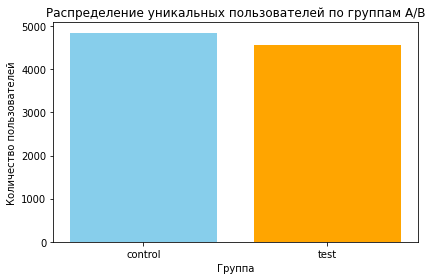

In [28]:
# Считаем уникальных пользователей в каждой группе
user_group_counts = abt[['user_id','group']].drop_duplicates() \
                         .groupby('group') \
                         .count() \
                         .rename(columns={'user_id': 'unique_users'})

plt.figure(figsize=(6,4))
plt.bar(user_group_counts.index, user_group_counts['unique_users'], color=['skyblue','orange'])
plt.title('Распределение уникальных пользователей по группам A/B')
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')
plt.tight_layout()
plt.show()

***Выводы:*** Не смотря на то, что гипотеза отвергается и вероятность попасть в группу А отличается от 50%, разница между группами визуально незначительна и укладывается в ожидаемые флуктуации случайного распределения. 

**Задача 3.2.** Сравнение воронок событий.
- Сравните пользовательский путь новых пользователей в тестовой и контрольной группах.
- Постройте классическую и последовательную воронки, выполните визуализацию и сделайте промежуточный вывод. 

In [29]:
# Определяем порядок шагов воронки
funnel_steps = [
    'install / open_web','introduction','registration',
    'main_page','onboarding_complete','first_deposit',
    'asset_purchase','second_deposit'
]

# Фильтруем события для воронки
abt_steps = abt[abt['event_name'].isin(funnel_steps)].copy()

# Функция для подсчёта уникальных пользователей на каждом шаге по группе
def get_funnel_for_group(df, group_name):
    df_group = df[df['group'] == group_name]
    counts = []
    for step in funnel_steps:
        users_at = df_group[df_group['event_name']==step]['user_id'].nunique()
        counts.append(users_at)
    return pd.DataFrame({
        'step': funnel_steps,
        'users': counts
    })

# Воронки по группам
funnel_control = get_funnel_for_group(abt_steps, 'control')
funnel_test    = get_funnel_for_group(abt_steps, 'test')

# Добавляем проценты
funnel_control['from_first_%'] = funnel_control['users'] / funnel_control['users'].iloc[0] * 100
funnel_control['from_prev_%']  = funnel_control['users'] / funnel_control['users'].shift(1) * 100

funnel_test['from_first_%'] = funnel_test['users'] / funnel_test['users'].iloc[0] * 100
funnel_test['from_prev_%']  = funnel_test['users'] / funnel_test['users'].shift(1) * 100

funnel_control['group_name'] = 'control'
funnel_test['group_name'] = 'test'

display(funnel_control, funnel_test)

,step,users,from_first_%,from_prev_%,group_name
0,install / open_web,4847,100.000000,NaN,control
1,introduction,4847,100.000000,100.000000,control
2,registration,4512,93.088508,93.088508,control
3,main_page,4161,85.846916,92.220745,control
4,onboarding_complete,4063,83.825046,97.644797,control
5,first_deposit,3228,66.597896,79.448683,control
6,asset_purchase,1773,36.579327,54.925651,control
7,second_deposit,654,13.492882,36.886633,control


,step,users,from_first_%,from_prev_%,group_name
0,install / open_web,4568,100.000000,NaN,test
1,introduction,4568,100.000000,100.000000,test
2,registration,4265,93.366900,93.366900,test
3,main_page,3919,85.792469,91.887456,test
4,onboarding_complete,3462,75.788091,88.338862,test
5,first_deposit,2987,65.389667,86.279607,test
6,asset_purchase,1977,43.279335,66.186810,test
7,second_deposit,974,21.322242,49.266566,test


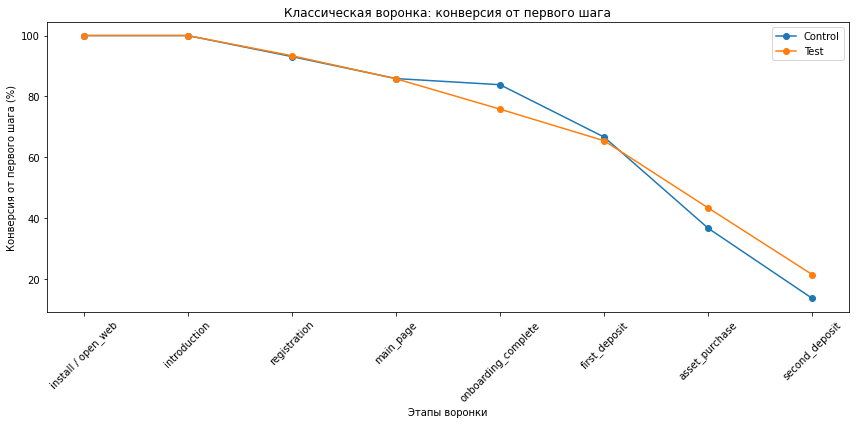

In [30]:
# Визуализация классической воронки
plt.figure(figsize=(12,6))
plt.plot(funnel_control['step'], funnel_control['from_first_%'], marker='o', label='Control')
plt.plot(funnel_test['step'],    funnel_test['from_first_%'],    marker='o', label='Test')
plt.title('Классическая воронка: конверсия от первого шага')
plt.xlabel('Этапы воронки')
plt.ylabel('Конверсия от первого шага (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

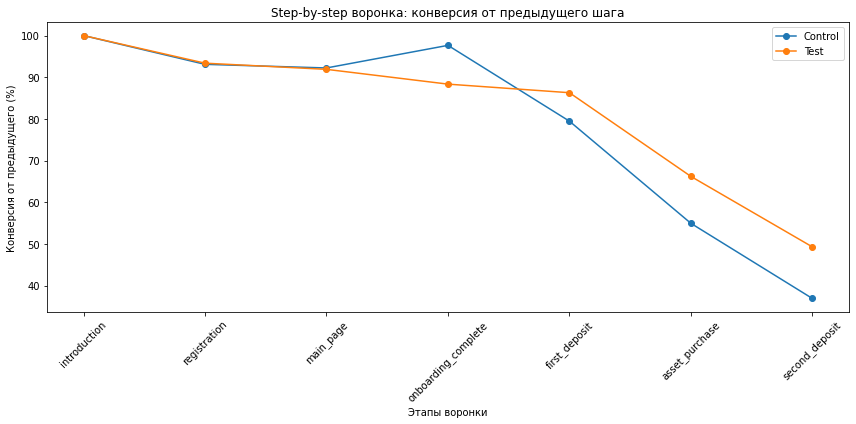

In [31]:
# Визуализация пошаговой воронки
plt.figure(figsize=(12,6))
plt.plot(funnel_control['step'], funnel_control['from_prev_%'], marker='o', label='Control')
plt.plot(funnel_test['step'],    funnel_test['from_prev_%'],    marker='o', label='Test')
plt.title('Step-by-step воронка: конверсия от предыдущего шага')
plt.xlabel('Этапы воронки')
plt.ylabel('Конверсия от предыдущего (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

***Выводы:*** 
1) На этапах: `install / open_web` → `introduction`, `introduction` → `registration`, `registration` → `main_page` конверсии практически идентичны в контрольной и тестовой группах.

2)Начиная с этапа:`onboarding_complete`начинают появляться различия между группами.

3)На последующих шагах: `first_deposit` → `asset_purchase`, `asset_purchase` → `second_deposit`тестовая группа стабильно превосходит контрольную: выше конверсия в покупку активов, заметно выше конверсия во второй депозит.

В целом пользователи в тестовой группе демонтрируют стабильный рост конверсии относительно контрольной, при прохождение шагов `first_deposit`, `asset_purchase`, `second_deposit`, которые являются наиболее проблемными для воронки.

**Задача 3.3.** Влияние новой фичи на конверсию во второй депозит с учётом уровня риска купленного актива.
- Проанализируйте, как категория риска купленного актива влияет на вероятность открытия второго депозита в тестовой и контрольной группах. 
- Сравните результаты и оцените, есть ли статистически значимая разница между группами. 

In [32]:
# Создаём итоговый список результатов
results = []

# Перечни значений, которые нужны
groups = ['control', 'test']
risk_levels = ['low', 'medium', 'high']

for group in groups:
    # Оставляем только пользователей текущей группы
    df_group = abt[abt['group'] == group]
    
    for risk in risk_levels:
        # Формируем список пользователей для данной группы риска
        df_filtered = df_group[df_group['risk_level'] == risk]['user_id'].unique()
        
        # Отбираем из основного датайфрейма строки для пользователей в данной группе риска
        df_level_abt = df_group[df_group['user_id'].isin(df_filtered)]
        funnel_for_level_abt = df_level_abt.groupby('event_name')['user_id'].nunique().reindex(funnel_steps).reset_index(name='n_users')
        funnel_for_level_abt['conversation'] = funnel_for_level_abt['n_users']/funnel_for_level_abt['n_users'][0]*100
        funnel_for_level_abt['conversation_from_previos_step'] = funnel_for_level_abt['n_users']/funnel_for_level_abt['n_users'].shift(1)*100
    
        conversation_abt = funnel_for_level_abt[funnel_for_level_abt['event_name'] == 'second_deposit']['conversation']
        df_abt = pd.DataFrame({
            'group': group,
            'risk_level': risk,
            'conversation_for_second_deposit': conversation_abt
        })
        results.append(df_abt)
# объединяем
df_conversion_abt = pd.concat(results, ignore_index=True)

display(df_conversion_abt)


,group,risk_level,conversation_for_second_deposit
0,control,low,49.824561
1,control,medium,44.537815
2,control,high,27.659574
3,test,low,57.459677
4,test,medium,47.043011
5,test,high,45.997286


***Гипотезы для проверки:***

 - Конверсия во второй депозит в рамках одной группы риска для контрольной и тестовой группы не различается.
  `H_0: p_control = p_test`
 - Конверсия во второй депозит в рамках одной группы риска для контрольной группы ниже, чем для тестовой.
  `H_1: p_control < p_test`
  
Мы будем использовать односторонний z-тест для долей, где проверяем, есть ли статистически значимое увеличение конверсии во второй депозит в тестовой группе в рамках одной группы риска.

In [33]:
ztest_results = []
for risk_level in ['low', 'medium', 'high']:
    # Отфильтруем пользователей заданной группы риска
    users_in_risk_level = abt[abt['risk_level'] == risk_level]['user_id'].unique()
    
    # Контрольная и тестовая подвыборки по группе риска
    control_conversation = abt[
        (abt['group'] == 'control') &
        (abt['user_id'].isin(users_in_risk_level))
    ]
    test_conversation = abt[
        (abt['group'] == 'test') &
        (abt['user_id'].isin(users_in_risk_level))
    ]

    # Считаем общее число пользователей на этапе first_deposit
    n_control = control_conversation[
        control_conversation['event_name'] == 'first_deposit'
    ]['user_id'].nunique()
    
    n_test = test_conversation[
        test_conversation['event_name'] == 'first_deposit'
    ]['user_id'].nunique()

    # Число успехов: second_deposit
    m_control = control_conversation[
        control_conversation['event_name'] == 'second_deposit'
    ]['user_id'].nunique()
    m_test = test_conversation[
        test_conversation['event_name'] == 'second_deposit'
    ]['user_id'].nunique()

    # Вероятности успеха
    p_control = m_control / n_control if n_control > 0 else 0
    p_test    = m_test / n_test    if n_test > 0 else 0

    # Проверка предпосылок
    cond_control = (p_control * n_control > 10) and ((1 - p_control) * n_control > 10)
    cond_test    = (p_test * n_test > 10) and ((1 - p_test) * n_test > 10)

    # Печатаем промежуточные значения
    print(f"Z-тест: уровень риска {risk_level}")
    print(f"control: n={n_control}, m={m_control}, p_control={round(p_control,4)}")
    print(f"test:    n={n_test}, m={m_test}, p_test={round(p_test,4)}")
    
    if cond_control and cond_test:
        print("Предпосылка о достаточном количестве данных выполняется.")
    else:
        print("Предпосылка о достаточном количестве данных НЕ выполняется.")

    # Если недостаточно данных — пропускаем
    if n_control == 0 or n_test == 0:
        print("Недостаточно данных для Z-теста — пропускаем.\n")
        continue

    # Z-тест пропорций (H1: p_control < p_test => alternative='smaller')
    stat_ztest, p_value_ztest = proportions_ztest(
        [m_control, m_test],
        [n_control, n_test],
        alternative='smaller'
    )

    # Интерпретация
    alpha = 0.05
    if p_value_ztest < alpha:
        print(f"pvalue={round(p_value_ztest,4)} < {alpha}")
        print("Отвергаем H₀: конверсия в control статистически ниже, чем в test.\n")
    else:
        print(f"pvalue={round(p_value_ztest,4)} >= {alpha}")
        print("H₀ не отвергаем: различие не статистически значимо.\n")

    # Можно собирать результаты Z-теста в список, если нужно
    ztest_results.append({
        'risk_level': risk_level,
        'n_control': n_control,
        'n_test': n_test,
        'm_control': m_control,
        'm_test': m_test,
        'p_control': p_control,
        'p_test': p_test,
        'z_stat': stat_ztest,
        'p_value': p_value_ztest
    })

# Таблица всех тестов
df_ztest_summary = pd.DataFrame(ztest_results)
df_ztest_summary

Z-тест: уровень риска low
control: n=285, m=142, p_control=0.4982
test:    n=496, m=285, p_test=0.5746
Предпосылка о достаточном количестве данных выполняется.
pvalue=0.0195 < 0.05
Отвергаем H₀: конверсия в control статистически ниже, чем в test.

Z-тест: уровень риска medium
control: n=595, m=265, p_control=0.4454
test:    n=744, m=350, p_test=0.4704
Предпосылка о достаточном количестве данных выполняется.
pvalue=0.1803 >= 0.05
H₀ не отвергаем: различие не статистически значимо.

Z-тест: уровень риска high
control: n=893, m=247, p_control=0.2766
test:    n=737, m=339, p_test=0.46
Предпосылка о достаточном количестве данных выполняется.
pvalue=0.0 < 0.05
Отвергаем H₀: конверсия в control статистически ниже, чем в test.



,risk_level,n_control,n_test,m_control,m_test,p_control,p_test,z_stat,p_value
0,low,285,496,142,285,0.498246,0.574597,-2.063426,1.953610e-02
1,medium,595,744,265,350,0.445378,0.470430,-0.914050,1.803452e-01
2,high,893,737,247,339,0.276596,0.459973,-7.678906,8.022634e-15


***Вывод:*** Низкорискованные и высокорискованные инвесторы показали статистически значимое улучшение конверсии во второй депозит в тестовой группе. Это говорит о положительном влиянии тестируемого онбординга для этих категорий.
В группе medium-risk различие между контрольной и тестовой группой не достигло статистической значимости на уровне 5%.

**Задача 3.4.** Анализ метрик А/В-эксперимента. Проанализируйте такие метрики:
- Ключевая метрика — средняя сумма всех депозитов на одного пользователя (включая тех, кто установил приложение или открыл веб-версию).
- Барьерная метрика — конверсия из регистрации в первый депозит.
- Вспомогательная метрика 1 — конверсия из первого депозита во второй.
- Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит.

Для каждой метрики выведите: 
- значения в контрольной и тестовой группах, 
- абсолютные и относительные изменения значений в тестовой группе по сравнению с контрольной.

После этого проверьте статистическую значимость различий метрик между группами эксперимента. 

Для ключевой метрики также изучите:
- накопленную динамику изменения по дням эксперимента для каждой группы, 
- стабильность p-value во время эксперимента.

Сделайте промежуточный вывод. 


Проанализируем ключевую миетрику - среднюю сумму всех депозитов на одного пользователя (включая тех, кто установил приложение или открыл веб-версию)

In [34]:
ARPU = (abt.groupby('group')['amount'].sum())/(abt.groupby('group')['user_id'].nunique())
delta_abs_ARPU = ARPU[1] - ARPU[0]
delta_rel_ARPU = 100*delta_abs_ARPU/ARPU[0]
print(ARPU)
print(f'Абсолютное изменение значений в тестовой группе по сравнению с контрольной составляет {delta_abs_ARPU:.2f}')
print(f'Относительное изменение значений в тестовой группе по сравнению с контрольной составляет {delta_rel_ARPU:.2f}%')

group
control    90.240149
test       92.460814
dtype: float64
Абсолютное изменение значений в тестовой группе по сравнению с контрольной составляет 2.22
Относительное изменение значений в тестовой группе по сравнению с контрольной составляет 2.46%


***Гипотезы для проверки***:

 - Средняя сумма всех депозитов на одного пользователя в контрольной и тестовой группах одинаковы.
H_0: ARPU_control = ARPU_test
 - Средняя сумма всех депозитов на одного пользователя в контрольной группе меньше, чем в тестовой.
H_1: ARPU_control < ARPU_test

In [35]:
# Сформируем датафрейм с суммарными депозитами на каждого пользователя 
deposit_all_users = abt.groupby(['group', 'user_id'])['amount'].sum().reset_index(name='sum_amount')
control_data = deposit_all_users[deposit_all_users['group'] == 'control']['sum_amount']
test_data = deposit_all_users[deposit_all_users['group'] == 'test']['sum_amount']

alpha = 0.05 

# Проведем t-тест
stat_ttest, p_value_ttest = ttest_ind(
    control_data, 
    test_data, 
    alternative='less' # поскольку Н1 о том, что средняя сумма всех депозитов на одного пользователя в тестовой группы больше
) 

if p_value_ttest>alpha:
    print(f'p-value t-теста Стьюдента = {round(p_value_ttest, 2)}')
    print('Нулевая гипотеза находит подтверждение!')
    print('Средняя сумма всех депозитов на одного пользователя в контрольной и тестовой группах одинаковы')
else:
    print(f'p-value теста Стьюдента ={round(p_value_ttest, 2)}')
    print('Нулевая гипотеза не находит подтверждения!')
    print('Cредняя сумма всех депозитов на одного пользователя в тестовой группы больше')

p-value t-теста Стьюдента = 0.17
Нулевая гипотеза находит подтверждение!
Средняя сумма всех депозитов на одного пользователя в контрольной и тестовой группах одинаковы


Рассчитаем и визуализируем накопленную динамику изменения средней суммы всех депозитов на одного пользователя по дням эксперимента и для каждой группы

     group       arpu        date
0  control   1.296703  2025-06-02
1     test   0.175000  2025-06-02
2  control  21.750355  2025-06-03
3     test  15.532847  2025-06-03
4  control  38.614068  2025-06-04


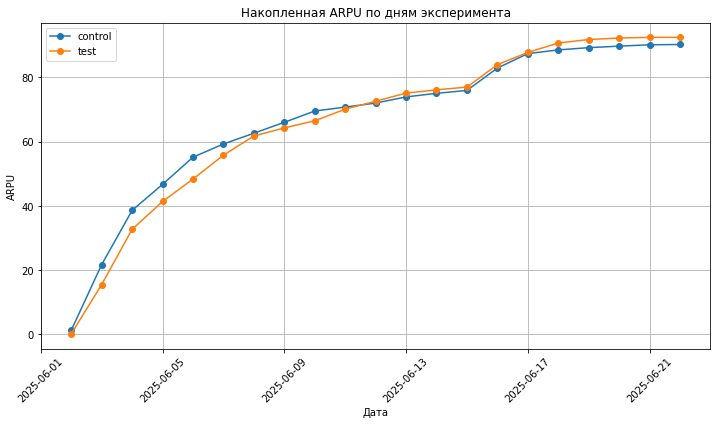

In [36]:
abt['event_dt'] = abt['event_ts'].dt.date
arpu_per_day = []

# Сортируем уникальные даты
for current_date in sorted(abt['event_dt'].unique()):
    # События до текущей даты включительно
    events_up_to_date = abt[abt['event_dt'] <= current_date]
    
    # Сумма депозитов до текущей даты (включая всех, кто сделал депозит)
    # и общее число уникальных пользователей (учитываем всех, не только платящих)
    arpu_for_group = (
        events_up_to_date.groupby('group')
                         .agg(
                             total_deposit_sum=('amount','sum'),
                             total_users=('user_id','nunique')
                         )
    )
    
    # Средняя сумма депозита на пользователя
    arpu_for_group['arpu'] = arpu_for_group['total_deposit_sum'] / arpu_for_group['total_users']
    
    # Превращаем в таблицу с колонкой даты
    arpu_for_group = arpu_for_group.reset_index()[['group','arpu']]
    arpu_for_group['date'] = current_date
    
    arpu_per_day.append(arpu_for_group)

# Конкатенируем в один DataFrame
arpu_df = pd.concat(arpu_per_day, ignore_index=True)

# Сортируем для красивого вывода
arpu_df = arpu_df.sort_values(by=['date','group'])

print(arpu_df.head())

# Визуализация
plt.figure(figsize=(12,6))
for grp in ['control', 'test']:
    plt.plot(
        arpu_df[arpu_df['group']==grp]['date'],
        arpu_df[arpu_df['group']==grp]['arpu'],
        marker='o',
        label=grp
    )

plt.title('Накопленная ARPU по дням эксперимента')
plt.xlabel('Дата')
plt.ylabel('ARPU')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

***Выводы:*** 
С самого начала эксперимента средние суммы депозитов на пользователя увеличиваются ежедневно для `control` и `test`. 
Это ожидаемо — с каждым днём накапливается всё больше депозитов от пользователей. 
В первые дни (около 2025-06-01 — 2025-06-07) ARPU в `control` немного выше, чем в `test`.
Однако со временем линии сближаются и затем `test` становится чуть выше, особенно ближе к середине эксперимента (примерно после 2025-06-08).
Ближе к середине и концу периода (примерно после 2025-06-14 и далее):
- значения ARPU в `test` и `control` становятся практически равными,
- разница между группами очень небольшая.

Эксперимент не демонстрирует явного и устойчивого преимущества тестовой группы по ARPU.
Разница между `control` и `test` мала, слабо выражена и не усиливается во времени.
Возможно, новая фича не сильно влияет на ключевую метрику ARPU, или эффект проявляется не сразу.

Изучим стабильность p-value по дням эксперимента.

          date   p_value
0   2025-06-02  0.965758
1   2025-06-03  0.992228
2   2025-06-04  0.981788
3   2025-06-05  0.977673
4   2025-06-06  0.995061
5   2025-06-07  0.905729
6   2025-06-08  0.628051
7   2025-06-09  0.757683
8   2025-06-10  0.894574
9   2025-06-11  0.605774
10  2025-06-12  0.403907
11  2025-06-13  0.302471
12  2025-06-14  0.311215
13  2025-06-15  0.310661
14  2025-06-16  0.310083
15  2025-06-17  0.432314
16  2025-06-18  0.170551
17  2025-06-19  0.131976
18  2025-06-20  0.134114
19  2025-06-21  0.155526
20  2025-06-22  0.165647


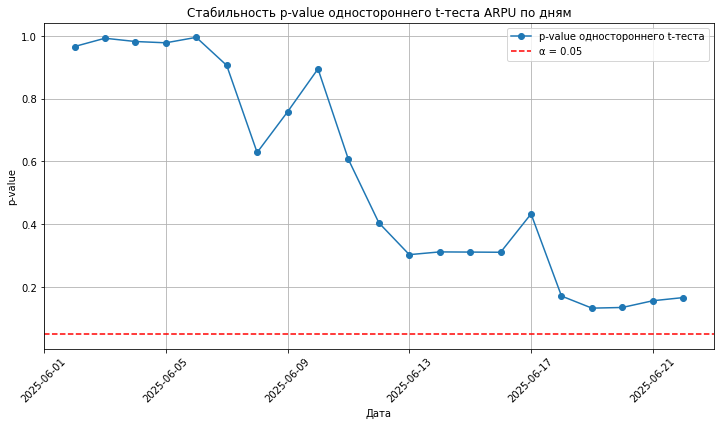

In [37]:
pval_records_arpu = []

# Сортируем уникальные даты
for current_date in sorted(abt['event_dt'].unique()):
    
    # События до текущей даты включительно
    events_up_to_date = abt[abt['event_dt'] <= current_date] 
    # Сумма депозитов на пользователя до текущей даты
    deposit_per_user = events_up_to_date.groupby(['group', 'user_id'])['amount'].sum().reset_index(name='sum_amount')
    
    # Объявление переменных с данными по каждой группе
    test = deposit_per_user[deposit_per_user['group'] == 'test']['sum_amount']
    control = deposit_per_user[deposit_per_user['group'] == 'control']['sum_amount']
    
    #Рассчитываем
    stat_ttest, p_value_ttest_arpu = ttest_ind(
    control, 
    test, 
    alternative='less' 
    ) 
    
    pval_records_arpu.append({
        'date': current_date,
        'p_value': p_value_ttest_arpu
    })
    
pvalue_df_arpu= pd.DataFrame(pval_records_arpu)
print(pvalue_df_arpu) 

# Визуализация
# Построим график p-value по датам
plt.figure(figsize=(12, 6))

plt.plot(
    pvalue_df_arpu['date'],
    pvalue_df_arpu['p_value'],
    marker='o',
    linestyle='-',
    label='p-value одностороннего t-теста'
)

# Горизонтальная линия уровня значимости
plt.axhline(y=0.05, color='red', linestyle='--', label='α = 0.05')

plt.title('Стабильность p-value одностороннего t-теста ARPU по дням')
plt.xlabel('Дата')
plt.ylabel('p-value')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

***Выводы:*** p-value одностороннего t-теста ARPU по дням остаётся выше 0.05 на всех датах, включая последние, что указывает на отсутствие устойчивого статистически значимого превосходства тестовой группы по ARPU. Итоговый т-тест, выполненный на всей выборке, также не выявил значимого эффекта (p≈0.17). 

Проанализируем барьерную метрику - Конверсия из регистрации в первый депозит.

In [38]:
# Пользователи, которые зарегистрировались
registered = abt[abt['event_name'] == 'registration']

# Пользователи, которые сделали первый депозит среди тех, кто зарегистрировался
purchased = abt[
    (abt['event_name'] == 'first_deposit') &
    (abt['user_id'].isin(registered['user_id']))
]

# Считаем число зарегистрированных по группам
reg_count = registered.groupby('group')['user_id'].nunique()

# Считаем число тех, кто сделал первый депозит по группам
purch_count = purchased.groupby('group')['user_id'].nunique()

# Объединяем в одну таблицу
barrier_df = (
    pd.DataFrame({
        'registered': reg_count,
        'first_deposit': purch_count
    })
    .fillna(0)  # если в какой-то группе нет данных
)

# Считаем конверсии
barrier_df['conv_reg_to_dep1'] = round(100*(barrier_df['first_deposit'] / barrier_df['registered']), 2)

display(barrier_df)

# Рассчитаем абсолютные и относительные отклонения
abs_delta_conv = barrier_df['conv_reg_to_dep1'][1] - barrier_df['conv_reg_to_dep1'][0]
rel_delta_conv = 100*(barrier_df['conv_reg_to_dep1'][1] - barrier_df['conv_reg_to_dep1'][0])/ barrier_df['conv_reg_to_dep1'][0]
print(f'Абсолютное отклонение конверсии из регистрации в депозит в тестовой группе по сравнению с контрольной{abs_delta_conv:.2f}, относительное{rel_delta_conv:.2f}%')

,registered,first_deposit,conv_reg_to_dep1
group,,,
control,4512,3228,71.54
test,4265,2987,70.04


Абсолютное отклонение конверсии из регистрации в депозит в тестовой группе по сравнению с контрольной-1.50, относительное-2.10%


***Гипотезы по барьерной метрике:***
- Конверсия из регистрации в первый депозит в контрольной группой и тестовой группах одинаковы.
   - H_0: conv_reg_to_dep1_control = conv_reg_to_dep1_test 
- Конверсия из регистрации в первый депозит в тестовой группе не меньше, чем в контрольной.
   - H_1: conv_reg_to_dep1_control <= conv_reg_to_dep1_test 

In [39]:
# Общее число пользователей в каждой группе на этапе `registered`
n_control = barrier_df['registered'][0]
n_test = barrier_df['registered'][1]

# Число успехов - количество пользователей в каждой группе на этапе `first_deposit`
m_control = barrier_df['first_deposit'][0]
m_test = barrier_df['first_deposit'][1]

# Считаем веротяность успеха в каждой группе
p_control = m_control/n_control
p_test = m_test/n_test

# Проверяем предпосылку о достаточном количестве данных
cond_control = (p_control * n_control > 10) and ((1 - p_control) * n_control > 10)
cond_test    = (p_test * n_test > 10) and ((1 - p_test) * n_test > 10)

if cond_control and cond_test:
    print("Предпосылка о достаточном количестве данных выполняется.")
else:
    print("Предпосылка о достаточном количестве данных НЕ выполняется.")

# Z-тест пропорций (H1: p_control <= p_test => alternative='smaller')
stat_ztest, p_value_ztest = proportions_ztest(
    [m_control, m_test],
    [n_control, n_test],
    alternative='smaller'
)

# Интерпретация
alpha = 0.05
if p_value_ztest < alpha:
    print(f"pvalue={round(p_value_ztest,4)} < {alpha}")
    print("Отвергаем H₀: конверсия в control статистически ниже, чем в test.\n")
else:
    print(f"pvalue={round(p_value_ztest,4)} >= {alpha}")
    print("H₀ не отвергаем: различие не статистически значимо.\n")

Предпосылка о достаточном количестве данных выполняется.
pvalue=0.9397 >= 0.05
H₀ не отвергаем: различие не статистически значимо.



***Выводы:*** p-value намного больше 0.05, следовательно мы не видим статистически значимого отличия между группами.
То есть разница в конверсии из регистрации в первый депозит между контролем и тестом существует, но она не подтверждается статистически — может быть просто следствием случайности.

Проанализтируем вспомогательную метрику 1 — конверсия из первого депозита во второй.

In [40]:
# Выбираем пользователей, которые купили первый депозит
first_deposit = abt[abt['event_name'] == 'first_deposit']

# И тех, кто сделал второй депозит среди тех, кто сделал первый
second_deposit = abt[
    (abt['event_name'] == 'second_deposit') &
    (abt['user_id'].isin(first_deposit['user_id']))
]

first_deposit_count = first_deposit.groupby('group')['user_id'].nunique()
second_deposit_count = second_deposit.groupby('group')['user_id'].nunique()

# Объединяем в одну таблицу
supportive_df = (
    pd.DataFrame({
        'first_deposit': first_deposit_count,
        'second_deposit': second_deposit_count
    })
    .fillna(0)  # если в какой-то группе нет данных
)

# Считаем конверсии
supportive_df['conv_first_dep_to_second'] = round(100*(supportive_df['second_deposit'] / supportive_df['first_deposit']), 2)

display(supportive_df)

# Рассчитаем абсолютные и относительные отклонения
abs_delta_conv = supportive_df['conv_first_dep_to_second'][1] - supportive_df['conv_first_dep_to_second'][0]
rel_delta_conv = 100*(supportive_df['conv_first_dep_to_second'][1] - supportive_df['conv_first_dep_to_second'][0])/ supportive_df['conv_first_dep_to_second'][0]
print(f'Абсолютное отклонение конверсии из певого депозита во второй в тестовой группе по сравнению с контрольной {abs_delta_conv:.2f}, относительное {rel_delta_conv:.2f}%')

,first_deposit,second_deposit,conv_first_dep_to_second
group,,,
control,3228,654,20.26
test,2987,974,32.61


Абсолютное отклонение конверсии из певого депозита во второй в тестовой группе по сравнению с контрольной 12.35, относительное 60.96%


***Гипотезы по вспомогательной метрике1:***

- Конверсия из первого депозита во второй в контрольной и тестовой группах одинаковы.
   - H_0: conversion_control = conversion_test 
- Конверсия из первого депозита во второй в контрольной группе меньше, чем в тестовой.
   - H_1: conversion_control < conversion_test 

In [41]:
# Общее число пользователей в каждой группе на этапе `first_deposit`
n_control = supportive_df['first_deposit'][0]
n_test = supportive_df['first_deposit'][1]

# Число успехов - количество пользователей в каждой группе на этапе `second_deposit`
m_control = supportive_df['second_deposit'][0]
m_test = supportive_df['second_deposit'][1]

# Считаем веротяность успеха в каждой группе
p_control = m_control/n_control
p_test = m_test/n_test

# Проверяем предпосылку о достаточном количестве данных
cond_control = (p_control * n_control > 10) and ((1 - p_control) * n_control > 10)
cond_test    = (p_test * n_test > 10) and ((1 - p_test) * n_test > 10)

if cond_control and cond_test:
    print("Предпосылка о достаточном количестве данных выполняется.")
else:
    print("Предпосылка о достаточном количестве данных НЕ выполняется.")

# Z-тест пропорций (H1: p_control < p_test => alternative='smaller')
stat_ztest, p_value_ztest = proportions_ztest(
    [m_control, m_test],
    [n_control, n_test],
    alternative='smaller'
)

# Интерпретация
alpha = 0.05
if p_value_ztest < alpha:
    print(f"pvalue={round(p_value_ztest,4)} < {alpha}")
    print("Отвергаем H₀: конверсия в control статистически ниже, чем в test.\n")
else:
    print(f"pvalue={round(p_value_ztest,4)} >= {alpha}")
    print("H₀ не отвергаем: различие не статистически значимо.\n")

Предпосылка о достаточном количестве данных выполняется.
pvalue=0.0 < 0.05
Отвергаем H₀: конверсия в control статистически ниже, чем в test.



***Выводы:*** Это означает, что конверсия из первого депозита во второй в тестовой группе статистически значимо выше, чем в контрольной. Т.е.пользователи в тестовой группе (которые прошли обновлённый онбординг с подробной информацией о рисках) чаще возвращаются и делают второй депозит после первого, чем пользователи из контрольной группы.

Проанализируем вспомогательную  метрику 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит.

In [42]:
# Берём пользователей, которые сделали хотя бы один депозит (first_deposit event)
paying = abt[abt['event_name'] == 'first_deposit']['user_id'].unique()

# Сумма всех депозитов на каждого пользователя (для тех, кто платил)
paying_deposits = (
    abt[abt['user_id'].isin(paying)]
    .groupby(['group','user_id'])['amount']
    .sum()
    .reset_index(name='total_deposit')
)

# Выборки по группам
control_vals = paying_deposits[paying_deposits['group']=='control']['total_deposit']
test_vals    = paying_deposits[paying_deposits['group']=='test']['total_deposit']

# Средние
mean_control = control_vals.mean()
mean_test    = test_vals.mean()

abs_diff = mean_test - mean_control
rel_diff = (mean_test / mean_control - 1) * 100

print("Средняя сумма депозитов (control):", round(mean_control,2))
print("Средняя сумма депозитов (test):   ", round(mean_test,2))
print("Абсолютное изменение:", round(abs_diff,2))
print("Относительное изменение (%):", round(rel_diff,2),"%")


Средняя сумма депозитов (control): 135.5
Средняя сумма депозитов (test):    141.4
Абсолютное изменение: 5.9
Относительное изменение (%): 4.35 %


***Гипотезы по вспмогательной метрике 2:***
- Средняя сумма всех депозитов на одного платящего пользователя в контрольной и тестовой группах одинаковы.
   - H_0: ARPPU_control = ARPPU_test 
- Средняя сумма всех депозитов на одного платящего пользователя в контрольной группе меньше, чем в тестовой.
   - H_1: ARPPU_control < ARPPU_test 

In [43]:
# Используем t-тест Стьюдента (Welch), потому что сравниваем средние двух независимых выборок
alpha = 0.05 
stat_ttest, p_value_ttest = ttest_ind(
    control_vals, 
    test_vals, 
    alternative='less' ## поскольку альтернативная гипотеза о том, что средняя сумма всех депозитов на одного пользователя в тестовой группы больше
) 

if p_value_ttest>alpha:
    print(f'p-value теста Стьюдента = {round(p_value_ttest, 2)}')
    print('Нулевая гипотеза находит подтверждение!')
    print('Интерпретация: средняя сумма всех депозитов на одного платящего пользователя в контрольной и тестовой группах одинаковы')
else:
    print(f'p-value теста Стьюдента = {round(p_value_ttest, 2)}')
    print('Нулевая гипотеза не находит подтверждения!')
    print('Интерпретация: средняя сумма всех депозитов на одного платящего пользователя в тестовой группе больше')

p-value теста Стьюдента = 0.02
Нулевая гипотеза не находит подтверждения!
Интерпретация: средняя сумма всех депозитов на одного платящего пользователя в тестовой группе больше


***Выводы:*** Обновлённый онбординг влияет не только на вовлечение, но и на поведение платежеспособных пользователей. Пользователи из тестовой группы, которые сделали хотя бы один депозит, в среднем совершают более крупные пополнения, чем в контрольной. Это признак увеличения монетизации среди платящих.

---

### 4. Анализ изменений суммы депозитов на платящего пользователя

Новая фича могла повлиять на поведение пользователей.
- Пользователи, которые раньше вносили небольшие суммы, могли стать более осторожными, сократить свои вложения или совсем перестать платить. Это отразится в снижении 25-го перцентиля суммы депозитов в тестовой группе.
- Пользователи, которые склонны к более крупным инвестициям, могли сильнее вовлечься в продукт и начать вносить больше средств. Это отразится в росте 75-го перцентиля.

Используя бутстрап, сравните разницы перцентилей (25, 50, 75) суммы всех депозитов на платящего пользователя в контрольной и тестовой группах:
- Постройте доверительные интервалы для разницы между группами для каждого перцентиля.
- Интерпретируйте изменения в контексте сформулированной выше гипотезы.
- Визуализируйте результат бутстрап-теста. 

--- 25-й перцентиль ---
25-й перцентиль контрольной группы: 95.00
25-й перцентиль тестовой группы:      48.00
95%-й доверительный интервал разности 25-х перцентилей: [-50.00, -44.00]



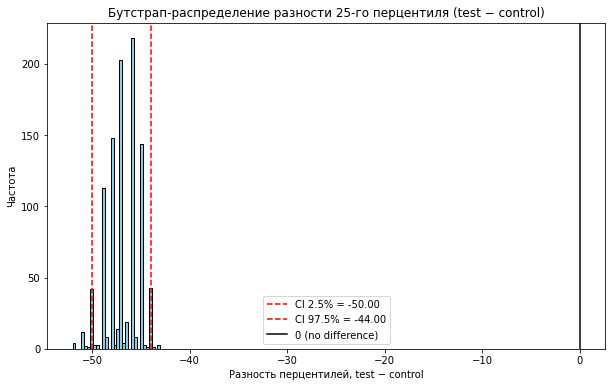

--- 50-й перцентиль ---
50-й перцентиль контрольной группы: 118.00
50-й перцентиль тестовой группы:      94.00
95%-й доверительный интервал разности 50-х перцентилей: [-27.01, -19.00]



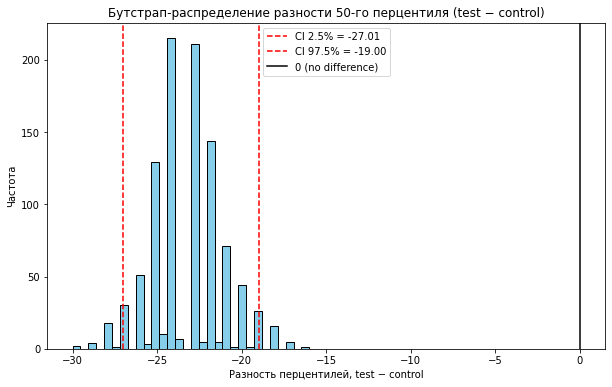

--- 75-й перцентиль ---
75-й перцентиль контрольной группы: 159.00
75-й перцентиль тестовой группы:      179.50
95%-й доверительный интервал разности 75-х перцентилей: [11.00, 30.00]



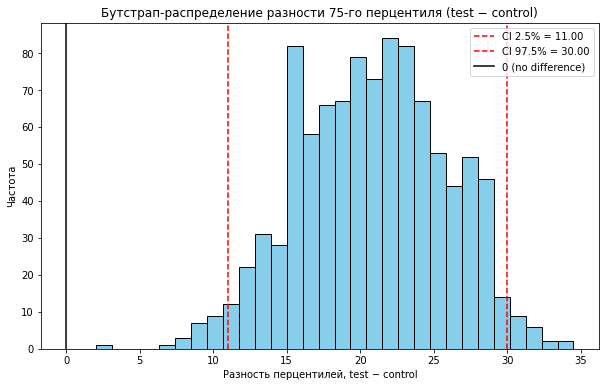

In [44]:
# Отбираем платящих пользователей
control_filttered = abt[(abt['amount'] > 0) & (abt['group'] == 'control')]
test_filttered = abt[(abt['amount'] > 0) & (abt['group'] == 'test')]

# Считаем суммы всех депозитов на платящего пользователя 
control = control_filttered.groupby('user_id')['amount'].sum()
test = test_filttered.groupby('user_id')['amount'].sum()

# Фиксируем seed для воспроизводимости
np.random.seed(42)

for j in [25, 50, 75]:
    n_iterations = 1000
    boot_diffs = []
    
    for i in range(n_iterations):
        # Бутстрап-выборки
        boot_control = np.random.choice(control, size=len(control), replace=True)
        boot_test    = np.random.choice(test, size=len(test), replace=True)

        # Считаем j-й перцентиль в каждой группе
        control_p = np.percentile(boot_control, j)
        test_p    = np.percentile(boot_test, j)

        # Разница перцентилей (test − control)
        boot_diffs.append(test_p - control_p)
    
    # Перевод в numpy-массив
    boot_diffs = np.array(boot_diffs)

    # Доверительный интервал для разности
    diff_ci = np.percentile(boot_diffs, [2.5, 97.5])

    # Печатаем результаты
    print(f"--- {j}-й перцентиль ---")
    print(f"{j}-й перцентиль контрольной группы: {np.percentile(control, j):.2f}")
    print(f"{j}-й перцентиль тестовой группы:      {np.percentile(test, j):.2f}")
    print(f"95%-й доверительный интервал разности {j}-х перцентилей: [{diff_ci[0]:.2f}, {diff_ci[1]:.2f}]\n")

    # Визуализация распределения разностей
    plt.figure(figsize=(10, 6))
    plt.hist(boot_diffs, bins=30, color='skyblue', edgecolor='black')
    plt.axvline(diff_ci[0], color='red', linestyle='--', label=f'CI 2.5% = {diff_ci[0]:.2f}')
    plt.axvline(diff_ci[1], color='red', linestyle='--', label=f'CI 97.5% = {diff_ci[1]:.2f}')
    plt.axvline(0, color='black', linestyle='-', label="0 (no difference)")
    plt.title(f"Бутстрап-распределение разности {j}-го перцентиля (test − control)")
    plt.xlabel("Разность перцентилей, test − control")
    plt.ylabel("Частота")
    plt.legend()
    plt.show()


***Выводы:*** 
- Анализ разности `25-го перцентиля` суммарных депозитов платящих пользователей показал, что нижний квартиль (25%) тестовой группы значительно ниже, чем у контрольной (95 против 48). Доверительный интервал [-50; -44] полностью отрицательный, что указывает на статистически значимое снижение перцентиля в тестовой группе. Это может быть связано с тем, что более осторожные инвесторы стали вносить меньшие суммы после прохождения обновлённого онбординга.
- Анализ `50-го перцентиля` (медианы) суммарных депозитов платящих пользователей показывает, что типичный плательщик в тестовой группе вносит статистически значимо меньшие суммы, чем в контрольной (медиана: 94 против 118).
Доверительный интервал разницы медиан полностью отрицательный ([-27.01; -19.00]), что подтверждает устойчивое снижение медианной суммы депозитов в тестовой группе.
- Результаты бутстрап-анализа `75-го перцентиля` суммарных депозитов показывают, что верхняя четверть платящих пользователей в тестовой группе вносит суммы статистически значимо выше, чем в контрольной.
75-й перцентиль составляет 179.50 в тесте против 159.00 в контроле, а 95 % доверительный интервал разницы находится в диапазоне [11.00; 30.00], полностью выше нуля. Это свидетельствует о том, что крупные инвесторы в тестовой группе более активно увеличивают суммы депозитов — что согласуется с гипотезой о вовлечении более активных плательщиков.


---

### 5. Выводы

Сформулируйте общий вывод. Зафиксируйте основные результаты и инсайты, которые, на ваш взгляд, помогут бизнесу улучшить продукт. Опишите, как новая фича повлияла на продукт: подтвердилась ли гипотеза, что делать дальше и есть ли риски. Объясните, какие результаты значимы и почему. 

Вывод предназначен для вашего заказчика и менеджеров продукта, поэтому сделайте его кратким, содержательным и понятным. 

Мы оценили влияние обновлённого онбординга — с подробной информацией о рисках активов — на поведение пользователей и ключевые бизнес-метрики продукта SollmaFin. Анализ охватывает период недельного наблюдения за новыми пользователями, разделёнными на контрольную (старый онбординг) и тестовую (новый онбординг) группы.

***Основные результаты***

`Ключевая метрика — ARPU (средняя сумма депозитов на пользователя)`
Нет устойчивой статистически значимой разницы между тестом и контролем в накопленной ARPU по дням.
В начале теста тестовая группа выглядела лучше, но эффект не стабильный и не сохраняется на протяжении эксперимента.
Вывод: обновлённый онбординг не улучшил общую монетизацию за счёт роста ARPU.

`Барьерная метрика — конверсия из регистрации → первый депозит`
Конверсия в обеих группах не имеет статистически значимого отличия.
Вывод: обновлённый онбординг не увеличил вероятность совершения первого депозита после регистрации.

`Вспомогательная метрика 1 — конверсия из первого → второго депозита`
Тестовая группа показала статистически значимо более высокую конверсию, чем контроль (p-value < 0.05).
Пользователи тестовой группы после первого депозита чаще совершали второй, чем в контроле.
Вывод: обновлённый онбординг усилил удержание после первого пополнения счета.

`Вспомогательная метрика 2 — средняя сумма депозитов у платящих`
Средняя сумма депозитов у платящих увеличилась в тесте, и разница между группами статистически значима (p-value < 0.05).
Вывод: среди тех, кто уже открывал депозит, пользователи тестовой группы вносят в среднем больше, чем в контрольной.

`Разложение по перцентилям (бутстрап-анализ)`
Меньшие плательщики стали вносить меньшие суммы после обновлённого онбординга.
Крупные плательщики стали вносить значительно больше, чем в контроле.
Это подтверждает предположение о различном влиянии онбординга: он усилил уверенность у опытных/амбициозных инвесторов и повысил их вклады, но усилил осторожность у менее активных.

***Риски и рекомендации***

Обновлённый онбординг может отпугивать часть мелких или осторожных инвесторов, снижая их активность или суммы инвестиций.
Это может привести к потере ранних депозитов или оттоку среди некрупных вкладчиков.

Рекомендации продукту:
- Сегментировать онбординг:
Добавить адаптивный путь для начинающих инвесторов, чтобы снизить страх перед рисками без отпугивания.
- Усилить обучение для ключевых сегментов:
Предоставить дополнительные подсказки или примеры для тех, кто потенциально может стать крупным инвестором.
- Мониторить поведение мелких плательщиков:
Рассмотреть A/B-тесты с уменьшением уровня «страшной» информации о рисках для новичков, чтобы не терять их активность.


***Выводы:***
Обновлённый онбординг не повысил массовую конверсию и ARPU,
но он усилил вовлечение платящих и повысил суммы депозитов среди крупных вкладчиков,
одновременно усилив осторожность менее активных пользователей.
Это важное открытие: фича работает не для всех одинаково — она смещает распределение вкладов, а не поднимает среднее массово.